# Parquet Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, normalize_tracksummary_df

from convert_all import convert_all


2025-11-19 02:21:55,088 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-11-19 02:21:55,089 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-11-19 02:21:55,089 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-11-19 02:21:55,089 - DEBUG - h5py._conv - Creating converter from 5 to 7


## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


In [116]:
# Configurable column selection for outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz", "perigee_d0", "perigee_z0",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id", "primary"
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

calo_columns_keep = [
    "event_id", "detector", "cell_id", "total_energy", "x", "y", "z", "contrib_particle_ids",
    "contrib_energies", "contrib_times"
]

In [117]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "hard_scatter"
dataset = "ttbar"
version = "v2"

base_root = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation")
output_base_dir = Path("./parquet_testing/v2")  # unified root like scripts

config = {
    "chunk_size": 8,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "hard_scatter",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
        "input_base_dir": base_root
    },
    "objects": ["tracker_hits", "particles", "tracks", "calo_hits"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "tracks_columns_keep": tracks_columns_keep,
    "calo_columns_keep": calo_columns_keep,
    "min_tracker_hits": 0,
    "min_calo_hits": 0,
    "output_format": "parquet",  # Specify parquet format (defaults to hdf5 if not set)
}


In [118]:
convert_all(config, chunk_index=0)

2025-11-19 02:52:50,949 - DEBUG - convert_all - Starting conversion with config: campaign=hard_scatter, dataset=ttbar, version=v2
2025-11-19 02:52:50,950 - DEBUG - convert_all - Input base directory: /global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v2
2025-11-19 02:52:50,950 - DEBUG - convert_all - Output base directory: /global/cfs/cdirs/m4958/data/ColliderML/simulation
2025-11-19 02:52:50,951 - DEBUG - convert_all - Output format: parquet
2025-11-19 02:52:50,951 - DEBUG - convert_all - Objects to convert: ['tracker_hits', 'particles', 'tracks', 'calo_hits']
2025-11-19 02:52:50,965 - INFO - convert_all - Found 1 runs. chunk_size=8, run_size=128, chunk_index=0, output_format=parquet
2025-11-19 02:52:50,965 - INFO - root - Processing 1 runs (128 events), chunk_size=8 events, 16 chunks
2025-11-19 02:52:50,966 - INFO - convert_all - Starting chunk processing for events 0-7
  0%|          | 0/1 [00:00<?, ?it/s]2025-11-19 02:52:50,987 - INFO - convert_all - Run 0: dir=/

2025-11-19 02:52:51,232 - DEBUG - pyedm4hep.event_batch - _load_calo_hits: start=0, stop=8
2025-11-19 02:52:51,348 - DEBUG - pyedm4hep.event_batch - calo ECalBarrelCollection: rows=106206 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-11-19 02:52:51,430 - DEBUG - pyedm4hep.event_batch - calo ECalEndcapCollection: rows=114790 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-11-19 02:52:51,493 - DEBUG - pyedm4hep.event_batch - calo HCalBarrelCollection: rows=44137 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-11-19 02:52:51,546 - DEBUG - pyedm4hep.event_batch - calo HCalEndcapCollection: rows=103366 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-11-19 02:52:51,554 - INFO - pyedm4hep.eve

Particles event:  0 (2034, 22) (1845, 10)
Particles event:  1 (2880, 22) (2719, 10)
Particles event:  2 (3239, 22) (3047, 10)
Particles event:  3 (4224, 22) (3951, 10)
Particles event:  4 (2392, 22) (2096, 10)
Particles event:  5 (5712, 22) (5055, 10)
Particles event:  6 (6774, 22) (6263, 10)
Particles event:  7 (8567, 22) (8189, 10)


2025-11-19 02:52:54,543 - DEBUG - root - Event 0: merged measurements 1636 -> 1636 in 0.009s
2025-11-19 02:52:54,554 - DEBUG - root - Event 1: merged measurements 2504 -> 2504 in 0.010s
2025-11-19 02:52:54,566 - DEBUG - root - Event 2: merged measurements 3180 -> 3180 in 0.011s
2025-11-19 02:52:54,578 - DEBUG - root - Event 3: merged measurements 3664 -> 3664 in 0.010s
2025-11-19 02:52:54,590 - DEBUG - root - Event 4: merged measurements 3203 -> 3203 in 0.010s
2025-11-19 02:52:54,605 - DEBUG - root - Event 5: merged measurements 6058 -> 6058 in 0.014s
2025-11-19 02:52:54,620 - DEBUG - root - Event 6: merged measurements 5767 -> 5767 in 0.013s
2025-11-19 02:52:54,633 - DEBUG - root - Event 7: merged measurements 3771 -> 3771 in 0.011s
2025-11-19 02:52:54,634 - INFO - convert_all - Run 0: tracker_hits rows=29783 events=8
2025-11-19 02:52:54,634 - DEBUG - convert_all - Digihits processing for run 0: 0.189s
2025-11-19 02:52:54,725 - DEBUG - convert_all - Track summary loading for run 0: 0.

## Step-by-step Conversion

Roadmap:

- Convert a small set of edm4hep events to h5

In [31]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "hard_scatter"
dataset = "ttbar"
version = "v2"

base_root = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation")
output_base_dir = Path("./parquet_testing/v1")  # unified root like scripts
input_base_dir = base_root / campaign / dataset / version

# Configurable column selection for outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz", "perigee_d0", "perigee_z0",
    "num_tracker_hits", "num_calo_hits", "primary", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

calo_columns_keep = [
    "event_id", "detector", "cell_id", "total_energy", "x", "y", "z", "contrib_particle_ids",
    "contrib_energies", "contrib_times"
]


run_dir = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/hard_scatter/ttbar/v2/runs/0")

config = {
    "chunk_size": 8,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": campaign,
    "dataset": dataset,
    "version": version,
    "common": {
        "output_base_dir": base_root,
        "input_base_dir": base_root
    },
    "objects": ["tracks", "tracker_hits", "particles", "calo_hits"],
    "min_tracker_hits": 1,
    "min_calo_hits": 1,
    "h5_output_dir": output_base_dir,
}

### Event lists and loading edm4hep events

In [32]:
from convert_all import *
from convert_all import _compute_paths, _prepare_output_dirs
from convert_digihits import *
from convert_tracks import *
from utils.path_utils import *
from utils.track_utils import *
from utils.driver import *
from utils.config import *


In [33]:
input_base_dir, output_base_dir, dataset_base, dataset_name_dot = _compute_paths(config)
particles_out_dir, trkhits_out_dir, tracks_out_dir, calo_out_dir = _prepare_output_dirs(output_base_dir, dataset_base, output_format="parquet")

In [34]:
particles_frames: list[pd.DataFrame] = []
digihits_frames: list[pd.DataFrame] = []
tracks_frames: list[pd.DataFrame] = []
seen_pairs_tracks: set[tuple[int, int]] = set()
seen_pairs_particles: set[tuple[int, int]] = set()
seen_pairs_hits: set[tuple[int, int]] = set()

In [38]:
run_size = 128
chunk_size = 8
run_dirs = get_run_paths(input_base_dir)
num_runs = len(run_dirs)
num_events = num_runs * run_size

In [39]:
input_base_dir

PosixPath('/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v2')

In [40]:
chunk_index = 0

In [41]:
start_event = chunk_index * chunk_size
end_event = min(num_events, start_event + chunk_size) - 1
start_run = start_event // run_size
start_local = start_event % run_size
end_run = end_event // run_size
end_local = end_event % run_size

In [42]:
print(f"Start event: {start_event}, End event: {end_event}, Start run: {start_run}, End run: {end_run}, Start local: {start_local}, End local: {end_local}")

Start event: 0, End event: 7, Start run: 0, End run: 0, Start local: 0, End local: 7


In [43]:
abs_run = start_run
run_dir = run_dirs[abs_run]

In [44]:
local_events = local_events_for_run(
        start_run=start_run,
        start_local=start_local,
        end_run=end_run,
        end_local=end_local,
        abs_run=abs_run,
        run_size=run_size,
    )

In [45]:
local_events

(0, 8)

In [46]:
edm4hep_path = run_dir / "edm4hep.root"
batch = EDM4hepEventBatch(str(edm4hep_path), events=local_events, condense_calo=False)

2025-11-19 02:27:20,752 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v2/runs/0/edm4hep.root, events=(0, 8), full_load=False, condense_calo=False


In [47]:
batch._ensure_loaded("tracker_hits")
batch._ensure_loaded("calo_hits")
batch._ensure_loaded("calo_contributions")

2025-11-19 02:27:21,531 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=8
2025-11-19 02:27:21,558 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=5601 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-19 02:27:21,586 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=3679 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-19 02:27:21,613 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=7514 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-19 02:27:21,638 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=4855 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-19 02:27:21,660 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=4144 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-19 02:27:21,686 - DEBUG - pye

### 0. Calo Loading

In [48]:
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
tracker_hits = batch.get_tracker_hits_df()

In [49]:
calo_hits

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,0,0,158470205747570704,3.068622e-05,-1.325397e+03,-284.027832,2866.199951,0,1,ECalBarrelCollection,1355.488525,3170.560059,-2.930489,0.441751,1.493706
1,0,1,160159081377114128,4.499315e-04,-1.276362e+03,-296.838135,2896.800049,1,8,ECalBarrelCollection,1310.424927,3179.412598,-2.913089,0.424823,1.534030
2,0,2,95138409001529360,2.867298e-08,-1.287750e+03,158.100006,1718.699951,8,9,ECalBarrelCollection,1297.418823,2153.421631,3.019432,0.646619,1.093426
3,0,3,139611708724488208,1.355792e-03,-1.107085e+03,-613.135254,2529.600098,9,25,ECalBarrelCollection,1265.532349,2828.506592,-2.635815,0.463879,1.443118
4,0,4,139330229452810256,3.495626e-04,-1.109037e+03,-608.423523,2524.500000,25,30,ECalBarrelCollection,1264.967163,2823.692871,-2.639821,0.464508,1.441712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368494,7,33840,18442521979136774420,1.137841e-08,2.100000e+02,-1412.489136,4004.500000,453091,453092,HCalEndcapCollection,1428.014526,4251.499023,-1.423204,0.342545,1.754655
368495,7,33841,18440551641414701332,3.524818e-03,1.200000e+02,-1202.489136,3851.500000,453092,453095,HCalEndcapCollection,1208.461914,4036.636230,-1.471333,0.304036,1.876011
368496,7,33842,18441958973348319508,2.809995e-04,-1.800000e+02,-1322.489136,3647.500000,453095,453096,HCalEndcapCollection,1334.682495,3884.022949,-1.706072,0.350784,1.730404
368497,7,33843,18440833099211346196,8.137631e-06,9.789613e-15,-1232.489136,3698.500000,453096,453098,HCalEndcapCollection,1232.489136,3898.452393,-1.570796,0.321667,1.818711


In [50]:
calo_contributions

,event_id,subentry,energy,time,particle_id,detector,hit_index,cellID,x,y,z
0,0,0,0.000031,35.064968,230,ECalBarrelCollection,0.0,158470205747570704,-1.325397e+03,-284.027832,2866.199951
1,0,1,0.000119,28.768900,230,ECalBarrelCollection,1.0,160159081377114128,-1.276362e+03,-296.838135,2896.800049
2,0,2,0.000053,28.769621,230,ECalBarrelCollection,1.0,160159081377114128,-1.276362e+03,-296.838135,2896.800049
3,0,3,0.000060,28.773624,230,ECalBarrelCollection,1.0,160159081377114128,-1.276362e+03,-296.838135,2896.800049
4,0,4,0.000063,28.774426,230,ECalBarrelCollection,1.0,160159081377114128,-1.276362e+03,-296.838135,2896.800049
...,...,...,...,...,...,...,...,...,...,...,...
1725258,7,99251,0.000633,17.389849,8512,HCalEndcapCollection,368495.0,18440551641414701332,1.200000e+02,-1202.489136,3851.500000
1725259,7,99252,0.000281,121.356125,8512,HCalEndcapCollection,368496.0,18441958973348319508,-1.800000e+02,-1322.489136,3647.500000
1725260,7,99253,0.000003,268.446564,8512,HCalEndcapCollection,368497.0,18440833099211346196,9.789613e-15,-1232.489136,3698.500000
1725261,7,99254,0.000005,270.662354,8512,HCalEndcapCollection,368497.0,18440833099211346196,9.789613e-15,-1232.489136,3698.500000


In [51]:
ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
ecal_time_min = -1.0  # ns
ecal_time_max = 10.0  # ns
hcal_time_min = -1.0  # ns
hcal_time_max = 10.0  # ns

run_calo_df = process_calohits_batch(
                    calo_hits,
                    calo_contributions,
                    ecal_energy_threshold=ecal_threshold_k4odd,
                    hcal_energy_threshold=hcal_threshold_k4odd,
                    time_min=ecal_time_min,
                    time_max=ecal_time_max,
                )

run_calo_df['event_id'] = run_calo_df['event_id'] + abs_run * run_size

2025-11-19 02:27:24,466 - DEBUG - convert_calorimeter - Batch: 1332502 contributions after timing filter


2025-11-19 02:27:24,744 - DEBUG - convert_calorimeter - Batch: 186732 cells pass energy threshold
2025-11-19 02:27:24,944 - DEBUG - convert_calorimeter - Batch: processed 186732 calorimeter cells in 0.541s


In [52]:
run_calo_df

,event_id,cellID,detector,total_energy,contrib_particle_ids,contrib_energies,contrib_times,x,y,z
0,7,18444773641517418769,ECalEndcapCollection,0.000852,"[7494, 7528]","[0.00016043514, 0.00069191254]","[11.689307, 11.716873]",-208.362228,836.204468,3369.050049
1,3,18432388875684747793,ECalEndcapCollection,0.000524,[829],[0.0005236059],[11.342083],213.963669,-596.515686,-3263.000000
2,7,18432670286237026577,ECalEndcapCollection,0.000301,[7659],[0.00030095986],[11.238082],-199.828323,602.370728,3268.050049
3,5,12384989187932176,ECalBarrelCollection,0.000643,[3032],[0.00064283266],[4.9427404],1043.442139,-891.979858,224.399994
4,6,18432107465132554513,ECalEndcapCollection,0.000475,"[1800, 1803]","[0.00027711416, 0.0001978605]","[11.220121, 11.218754]",-621.079163,141.335205,3263.000000
...,...,...,...,...,...,...,...,...,...,...
186727,7,18415781796225774097,ECalEndcapCollection,0.000142,[3591],[0.00014161991],[11.331793],-326.988953,-35.700001,-3379.149902
186728,1,2251735407598097,ECalEndcapCollection,0.000433,[1457],[0.00043284218],[12.030323],426.108917,-828.813843,-3323.600098
186729,2,18425070526291995153,ECalEndcapCollection,0.000493,[1653],[0.0004928486],[11.659455],-450.589020,219.761276,-3394.300049
186730,5,1970389279774736,ECalBarrelCollection,0.000862,[1386],[0.00086197065],[4.6494775],-451.112061,-1288.984985,35.700001


#### Debug

In [20]:
# Test: Apply timing window to contributions, merge ALL, then threshold at cell level
print("=== Test: Threshold AFTER merging (cell level) ===\n")

ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
ecal_time_min = -1.0  # ns
ecal_time_max = 10.0  # ns
hcal_time_min = -1.0  # ns
hcal_time_max = 10.0  # ns

calo_contributions['r'] = np.sqrt(calo_contributions['x']**2 + calo_contributions['y']**2 + calo_contributions['z']**2)
calo_contributions['dt'] = calo_contributions['r']/300 - 0.1  # in ns

ecal_mask = calo_contributions['detector'].str.contains('ECal')
hcal_mask = calo_contributions['detector'].str.contains('HCal')

print(f"Contributions before any filtering: {len(calo_contributions)}")
print(f"Digi hits before any filtering: {len(calo_hits)}")

print(f"Shared unique cellIDs between calo_contributions and calo_hits: {len(calo_contributions.merge(calo_hits, on=['event_id', 'cellID']))}")

# Step 1: Apply timing cuts to contributions only (NOT energy)
if 'time' in calo_contributions.columns:
    contributions_timing_filtered = calo_contributions[
    ((ecal_mask) &
        (calo_contributions['time'] - calo_contributions['dt'] >= ecal_time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= ecal_time_max)) |
    ((hcal_mask) & 
        (calo_contributions['time'] - calo_contributions['dt'] >= hcal_time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= hcal_time_max))
].copy()
    print(f"Contributions after TIMING filter only: {len(contributions_timing_filtered)}")
else:
    contributions_timing_filtered = calo_contributions.copy()
    print("No timing filter (no time column)")

print(f"Shared unique cellIDs between contributions_timing_filtered and calo_hits: {len(contributions_timing_filtered.merge(calo_hits, on=['event_id', 'cellID']).cellID.unique())}")

=== Test: Threshold AFTER merging (cell level) ===

Contributions before any filtering: 2502632
Digi hits before any filtering: 502076
Contributions before any filtering: 2502632
Digi hits before any filtering: 502076
Shared unique cellIDs between calo_contributions and calo_hits: 2502632
Shared unique cellIDs between calo_contributions and calo_hits: 2502632
Contributions after TIMING filter only: 1634785
Contributions after TIMING filter only: 1634785
Shared unique cellIDs between contributions_timing_filtered and calo_hits: 233617
Shared unique cellIDs between contributions_timing_filtered and calo_hits: 233617


##### Testing Nested Calorimeter Structure

Now let's test the full workflow:
1. Filter contributions by timing
2. Aggregate by (event_id, cellID, particle_id) 
3. Group to cell level with nested contributions
4. Merge with calo_hits to get positions
5. Apply cell-level energy threshold

In [21]:
# Step 1: Apply timing filters to contributions (already have this from above)
print(f"Contributions after timing filter: {len(contributions_timing_filtered)}")

# Step 2: Aggregate by (event_id, cellID, particle_id) with energy-weighted time
contributions_timing_filtered['energy_time'] = contributions_timing_filtered['energy'] * contributions_timing_filtered['time']

contrib_per_particle = (
    contributions_timing_filtered.groupby(['event_id', 'cellID', 'particle_id'], sort=False)
    .agg(
        energy=('energy', 'sum'),
        energy_time=('energy_time', 'sum'),
        detector=('detector', 'first'),
    )
    .reset_index()
)

# Calculate energy-weighted time per particle contribution
contrib_per_particle['time'] = contrib_per_particle['energy_time'] / contrib_per_particle['energy']
contrib_per_particle = contrib_per_particle.drop(columns=['energy_time'])

print(f"Particle contributions per cell: {len(contrib_per_particle)}")
contrib_per_particle.head()

Contributions after timing filter: 1634785
Particle contributions per cell: 378758
Particle contributions per cell: 378758


,event_id,cellID,particle_id,energy,detector,time
0,1,18430137110230026256,361,0.000270,ECalBarrelCollection,8.479478
1,1,18430137110230026256,383,0.000179,ECalBarrelCollection,8.473036
2,1,18430137110230091792,383,0.000504,ECalBarrelCollection,8.490618
3,1,18430137110230157328,383,0.001057,ECalBarrelCollection,8.510907
4,1,18429855635253512208,383,0.000455,ECalBarrelCollection,8.527136


In [22]:
# Step 3a: First group by cell to get total energy (for threshold)
cell_energy = (
    contrib_per_particle.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
    )
    .reset_index()
)

print(f"Cells before energy threshold: {len(cell_energy)}")

# Step 3b: Apply cell-level energy thresholds BEFORE creating nested lists
ecal_mask = cell_energy['detector'].str.contains('ECal', na=False)
hcal_mask = cell_energy['detector'].str.contains('HCal', na=False)

energy_threshold_mask = (
    (ecal_mask & (cell_energy['total_energy'] >= ecal_threshold_k4odd)) |
    (hcal_mask & (cell_energy['total_energy'] >= hcal_threshold_k4odd))
)

cells_passing_threshold = cell_energy[energy_threshold_mask][['event_id', 'cellID']].copy()
print(f"Cells after energy threshold: {len(cells_passing_threshold)}")

# Step 3c: Filter contributions to only cells passing threshold, THEN create nested lists
contrib_filtered = contrib_per_particle.merge(
    cells_passing_threshold,
    on=['event_id', 'cellID'],
    how='inner'
)

print(f"Contributions after filtering to passing cells: {len(contrib_filtered)}")

# Step 3d: Now group to create nested lists (much smaller dataset!)
cell_level = (
    contrib_filtered.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
        contrib_particle_ids=('particle_id', list),
        contrib_energies=('energy', list),
        contrib_times=('time', list),
    )
    .reset_index()
)

print(f"Cells with nested contributions: {len(cell_level)}")
print(f"\nExample cell with contributions:")
print(cell_level.iloc[0])
print(f"\nNumber of contributions in first cell: {len(cell_level.iloc[0]['contrib_particle_ids'])}")

Cells before energy threshold: 237014
Cells after energy threshold: 211158
Contributions after filtering to passing cells: 352248
Cells with nested contributions: 211158

Example cell with contributions:
event_id                                                               1
cellID                                              18430137110230026256
detector                                            ECalBarrelCollection
total_energy                                                    0.000448
contrib_particle_ids                                          [361, 383]
contrib_energies        [0.00026952987536787987, 0.00017890887102112174]
contrib_times                      [8.479477882385254, 8.47303581237793]
Name: 0, dtype: object

Number of contributions in first cell: 2
Cells with nested contributions: 211158

Example cell with contributions:
event_id                                                               1
cellID                                              18430137110230026256


In [23]:
# Step 4: Merge with calo_hits to get cell positions (x, y, z)
calo_cells = cell_level.merge(
    calo_hits[['event_id', 'cellID', 'x', 'y', 'z']],
    on=['event_id', 'cellID'],
    how='inner'
)

calo_cells.rename(columns={"cellID": "cell_id"}, inplace=True)

print(f"Final cells after merging with calo_hits: {len(calo_cells)}")
print(f"Columns: {calo_cells.columns.tolist()}")
calo_cells.head()

Final cells after merging with calo_hits: 211158
Columns: ['event_id', 'cell_id', 'detector', 'total_energy', 'contrib_particle_ids', 'contrib_energies', 'contrib_times', 'x', 'y', 'z']


,event_id,cell_id,detector,total_energy,contrib_particle_ids,contrib_energies,contrib_times,x,y,z
0,1,18430137110230026256,ECalBarrelCollection,0.000448,"[361, 383]","[0.00026952987536787987, 0.00017890887102112174]","[8.479477882385254, 8.47303581237793]",-545.237732,1129.743164,-300.899994
1,1,18430137110230091792,ECalBarrelCollection,0.000504,[383],[0.0005035966169089079],[8.490617752075195],-547.170288,1134.408691,-300.899994
2,1,18430137110230157328,ECalBarrelCollection,0.001057,[383],[0.0010573721956461668],[8.510907173156738],-549.102844,1139.074341,-300.899994
3,1,18429855635253512208,ECalBarrelCollection,0.000455,[383],[0.00045471027260646224],[8.527135848999023],-551.035400,1143.739868,-306.000000
4,1,18429855635253577744,ECalBarrelCollection,0.000231,[383],[0.00023131832131184638],[8.54515552520752],-552.967957,1148.405518,-306.000000


### 1. Particle Loading

In [110]:
%%time
parts_all = batch.get_particles_df()
parents_all = batch.get_parents_df()

CPU times: user 0 ns, sys: 7.48 ms, total: 7.48 ms
Wall time: 6.8 ms


In [111]:
%%time
particles_root_path = Path(run_dir) / "particles.root"
included_columns = ["event_id", "vx", "vy", "vz", "px", "py", "pz", "vertex_primary", "perigee_d0", "perigee_z0"]
digi_particles_df_run = load_root_file(str(particles_root_path), included_columns=included_columns, events=local_events)
digi_particles_df_run

CPU times: user 46.1 ms, sys: 18.4 ms, total: 64.5 ms
Wall time: 98.5 ms


event_id          vx          vy           vz         px  \
entry subentry                                                             
0     0                0    0.009162   -0.003694   196.070236  12.111033   
      1                0    0.009162   -0.003694   196.070236  43.898525   
      2                0    0.009162   -0.003694   196.070236  32.571106   
      3                0    0.009162   -0.003694   196.070236   1.361503   
      4                0    0.009162   -0.003694   196.070236   0.518549   
...                  ...         ...         ...          ...        ...   
7     8184             7  657.615601 -281.632172 -2146.276855   0.014770   
      8185             7  657.615601 -281.632172 -2146.276855   0.034454   
      8186             7  593.444824 -561.066956 -1579.389038   0.000007   
      8187             7    0.007445    0.028977    -8.896443  -0.000272   
      8188             7    0.007445    0.028977    -8.896443   0.069668   

                       py          pz  vertex_primary  perigee_d0  perigee_z0  
entry subentry                                                                 
0     0         48.026073   72.044685               1   -0.009787  196.072189  
      1        -20.764874  106.692947               1    0.000578  196.048569  
      2         34.368645  -20.173618               1   -0.009191  196.071777  
      3          0.841040   -0.745837               1   -0.007958  196.072952  
      4          0.328355   -0.336921               1   -0.008023  196.073395  
...                   ...         ...             ...         ...         ...  
7     8184      -0.005640   -0.048399               1         NaN         NaN  
      8185      -0.015633   -0.111480               1         NaN         NaN  
      8186      -0.000004   -0.000075               1         NaN         NaN  
      8187      -0.157103  -70.861534               1    0.000000    0.000000  
      8188      -0.035720  -19.085926               1    0.000000    0.000000  

[33165 rows x 10 columns]

#### Debug

In [76]:
particles_event = parts_all[parts_all.event_id == 5]
parents_event = parents_all[parents_all.event_id == 5]
digi_particles_event = digi_particles_df_run[digi_particles_df_run.event_id == 5]

In [78]:
parents_event

,event_id,subentry,particle_id,collectionID
19627,5,0,0,2714477136
19628,5,1,0,2714477136
19629,5,2,0,2714477136
19630,5,3,4,2714477136
19631,5,4,4,2714477136
...,...,...,...,...
27789,5,8162,5676,2714477136
27790,5,8163,496,2714477136
27791,5,8164,496,2714477136
27792,5,8165,494,2714477136


In [72]:
particles_event

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
14769,5,0,2212,0,1.000000,0.078581,0.938270,-0.026015,0.003744,-38.220307,...,6999.999937,0,0,0.026283,7000.000000,6999.061730,0,False,0,0
14770,5,1,21,0,0.000000,0.078581,0.000000,-0.026015,0.003744,-38.220307,...,2923.400733,0,1,0.026283,2923.400733,2923.400733,1,False,0,0
14771,5,2,2203,0,1.333333,0.078581,0.771330,-0.026015,0.003744,-38.220307,...,3040.588619,1,2,0.026283,3040.588717,3039.817387,2,False,0,0
14772,5,3,1,0,-0.333333,0.078581,0.330000,-0.026015,0.003744,-38.220307,...,1036.010541,2,3,0.026283,1036.010593,1035.680593,3,False,0,0
14773,5,4,2212,0,1.000000,0.078581,0.938270,-0.026015,0.003744,-38.220307,...,-6999.999937,3,3,0.026283,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20476,5,5707,11,1426063360,-1.000000,18.052923,0.000511,-363.852461,-168.032737,5304.445536,...,0.115101,8162,8163,400.778759,0.153060,0.152549,5707,True,0,11
20477,5,5708,22,1107296256,0.000000,0.078618,0.000000,-0.025926,0.003578,-38.209174,...,7.125839,8163,8164,0.026172,7.127594,7.127594,5708,True,0,0
20478,5,5709,22,1107296256,0.000000,0.078618,0.000000,-0.025926,0.003578,-38.209174,...,8.222474,8164,8165,0.026172,8.223498,8.223498,5709,True,0,0
20479,5,5710,22,1107296256,0.000000,0.078584,0.000000,-0.026009,0.003723,-38.219367,...,4.146980,8165,8166,0.026274,4.147099,4.147099,5710,True,0,0


In [107]:
 # Ensure we have the link-range columns
if {"parents_begin", "parents_end"}.issubset(particles_event.columns):
    print("Adding parent_id column")
    parent_id_series = pd.Series([-1] * len(particles_event), dtype="int64", index=particles_event.index)
    # Rows with at least one parent
    has_parent = particles_event["parents_end"].values > particles_event["parents_begin"].values
    if has_parent.any():
        begin_idx = particles_event.loc[has_parent, "parents_begin"].astype(int).values
        # parents df is per-event; iloc indices refer to per-event flattened list
        parent_ids = parents_event.iloc[begin_idx]["particle_id"].values
        parent_id_series.loc[has_parent] = parent_ids
    particles_event = particles_event.copy()
    particles_event["parent_id"] = parent_id_series

Adding parent_id column


In [108]:
parent_id_series

14769      -1
14770       0
14771       0
14772       0
14773      -1
         ... 
20476    5676
20477     496
20478     496
20479     494
20480     494
Length: 5712, dtype: int64

In [109]:
particles_event

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,parent_id
14769,5,0,2212,0,1.000000,0.078581,0.938270,-0.026015,0.003744,-38.220307,...,0,0,0.026283,7000.000000,6999.061730,0,False,0,0,-1
14770,5,1,21,0,0.000000,0.078581,0.000000,-0.026015,0.003744,-38.220307,...,0,1,0.026283,2923.400733,2923.400733,1,False,0,0,0
14771,5,2,2203,0,1.333333,0.078581,0.771330,-0.026015,0.003744,-38.220307,...,1,2,0.026283,3040.588717,3039.817387,2,False,0,0,0
14772,5,3,1,0,-0.333333,0.078581,0.330000,-0.026015,0.003744,-38.220307,...,2,3,0.026283,1036.010593,1035.680593,3,False,0,0,0
14773,5,4,2212,0,1.000000,0.078581,0.938270,-0.026015,0.003744,-38.220307,...,3,3,0.026283,7000.000000,6999.061730,4,False,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20476,5,5707,11,1426063360,-1.000000,18.052923,0.000511,-363.852461,-168.032737,5304.445536,...,8162,8163,400.778759,0.153060,0.152549,5707,True,0,11,5676
20477,5,5708,22,1107296256,0.000000,0.078618,0.000000,-0.025926,0.003578,-38.209174,...,8163,8164,0.026172,7.127594,7.127594,5708,True,0,0,496
20478,5,5709,22,1107296256,0.000000,0.078618,0.000000,-0.025926,0.003578,-38.209174,...,8164,8165,0.026172,8.223498,8.223498,5709,True,0,0,496
20479,5,5710,22,1107296256,0.000000,0.078584,0.000000,-0.026009,0.003723,-38.219367,...,8165,8166,0.026274,4.147099,4.147099,5710,True,0,0,494


In [83]:
parent_ids

array([  0,   0,   0, ..., 496, 494, 494], shape=(5710,), dtype=int32)

In [67]:
print(f"""
Number of particles: {len(particles_event)}
Number of particles with at least 1 tracker hit: {len(particles_event[particles_event.num_tracker_hits > 0])}
Number of particles with at least 1 calo hit: {len(particles_event[particles_event.num_calo_hits > 0])}
Number of particles with at least 1 calo hit OR tracker hit: {len(particles_event[(particles_event.num_calo_hits > 0) | (particles_event.num_tracker_hits > 0)])}
Number of particles created in generator: {len(particles_event[~particles_event.created_in_simulation])}
Number of particles with at least 1 tracker hit OR 1 calo hit OR created in generator: {len(particles_event[(particles_event.num_tracker_hits > 0) | (particles_event.num_calo_hits > 0) | (~particles_event.created_in_simulation)])}
""")


Number of particles: 5712
Number of particles with at least 1 tracker hit: 1265
Number of particles with at least 1 calo hit: 3664
Number of particles with at least 1 calo hit OR tracker hit: 4533
Number of particles created in generator: 1111
Number of particles with at least 1 tracker hit OR 1 calo hit OR created in generator: 5432



#### Run Particle EDM4hep <-> ACTS Matching

In [112]:
min_particle_energy = None
min_tracker_hits = 0
min_calo_hits = 0
df_run = build_particles_df_with_parents_and_vertex(
                batch,
                str(edm4hep_path),
                digi_particles_df_run,
                local_events=local_events,
                min_particle_energy=min_particle_energy,
                min_tracker_hits=min_tracker_hits,
                min_calo_hits=min_calo_hits,
            )
global_event_nums = df_run["event_id"] + abs_run * run_size
df_run["event_id"] = global_event_nums
particles_frames.append(df_run)

2025-11-19 02:51:54,365 - DEBUG - convert_particles - Building particles DataFrame with parents and vertex info for 2 events
2025-11-19 02:51:54,366 - DEBUG - convert_particles - Particles DataFrame shape: (35822, 22), with columns Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits'],
      dtype='object'), and unique events 8
2025-11-19 02:51:54,367 - DEBUG - convert_particles - Parents DataFrame shape: (45662, 4), with columns Index(['event_id', 'subentry', 'particle_id', 'collectionID'], dtype='object'), and unique events 8
2025-11-19 02:51:54,367 - DEBUG - convert_particles - Particles root DataFrame shape: (33165, 10), with columns Index(['event_id', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'vertex_primary',
       'perigee_d0', 'perigee_z0'],
      dtype='obj

2025-11-19 02:51:54,479 - DEBUG - convert_particles - Event 7: 8189 particles after min_calo_hits filter 
2025-11-19 02:51:54,480 - DEBUG - convert_particles - Event 7: 8189 particles after particle cut mask
2025-11-19 02:51:54,481 - DEBUG - root - Event 7: processed 8189 particles in 0.015s
2025-11-19 02:51:54,482 - DEBUG - convert_particles - Built run-level particles df rows=33166 time=0.117s


Particles event:  0 (2034, 22) (1845, 10)
Particles event:  1 (2880, 22) (2719, 10)
Particles event:  2 (3239, 22) (3047, 10)
Particles event:  3 (4224, 22) (3951, 10)
Particles event:  4 (2392, 22) (2096, 10)
Particles event:  5 (5712, 22) (5055, 10)
Particles event:  6 (6774, 22) (6263, 10)
Particles event:  7 (8567, 22) (8189, 10)


In [113]:
df_event = df_run[df_run.event_id == 5]

In [114]:
df_event

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,primary,vertex_primary,parent_id,perigee_d0,perigee_z0,event_id
13659,39,-321,0.493680,58.601590,-1.0,-0.026015,0.003744,-38.220306,0.078581,0.991475,0.437857,58.589485,0,0,True,1,9,0.013934,-37.015617,5
13660,40,111,0.134980,74.864401,0.0,-0.026015,0.003744,-38.220306,0.078581,1.094013,0.675108,74.853241,0,0,True,1,9,0.016848,-37.045673,5
13661,41,213,0.654662,160.566303,1.0,-0.026015,0.003744,-38.220306,0.078581,-0.299584,0.146204,160.564621,0,0,True,1,9,NaN,NaN,5
13662,42,-211,0.139570,154.460656,-1.0,-0.026015,0.003744,-38.220306,0.078581,0.146140,-0.204730,154.460388,0,0,True,1,9,NaN,NaN,5
13663,43,2214,1.447397,1497.771223,1.0,-0.026015,0.003744,-38.220306,0.078581,0.030522,-0.314543,1497.770508,0,0,True,1,9,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18709,5707,11,0.000511,0.153060,-1.0,-363.852448,-168.032730,5304.445312,18.052923,-0.091750,0.041962,0.115101,0,11,False,1,5676,304.140656,5006.681641,5
18710,5708,22,0.000000,7.127594,0.0,-0.025926,0.003578,-38.209175,0.078618,0.013824,-0.157568,7.125839,0,0,False,1,496,-0.025515,-37.946518,5
18711,5709,22,0.000000,8.223498,0.0,-0.025926,0.003578,-38.209175,0.078618,0.108931,-0.070555,8.222474,0,0,False,1,496,-0.011091,-36.707298,5
18712,5710,22,0.000000,4.147099,0.0,-0.026009,0.003723,-38.219368,0.078584,0.006881,-0.030661,4.146980,0,0,False,1,494,0.000000,0.000000,5


In [62]:
df_run[df_run.parent_id.isna()]

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,primary,vertex_primary,parent_id,perigee_d0,perigee_z0,event_id
18712,5710,22,0.0,4.147099,0.0,-0.026009,0.003723,-38.219368,0.078584,0.006881,-0.030661,4.146980,0,0,False,1,NaN,0.000000,0.000000,5
18713,5711,22,0.0,8.008543,0.0,-0.026009,0.003723,-38.219368,0.078584,0.072414,-0.237186,8.004703,0,0,False,1,NaN,-0.023789,-37.859303,5


In [115]:
# Find columns with NaN values
nan_cols = df_run.columns[df_run.isna().any()].tolist()
print("Columns with NaN values:", nan_cols)

# For each such column, show the entries (rows) with NaNs
for col in nan_cols:
    nan_entries = df_run[df_run[col].isna()]
    print(f"\nEntries with NaN in column '{col}':")
    print(nan_entries)

Columns with NaN values: ['perigee_d0', 'perigee_z0']

Entries with NaN in column 'perigee_d0':
       particle_id  pdg_id      mass       energy  charge          vx  \
0               76     213  0.738762  2491.611858     1.0    0.009162   
1               77    -211  0.139570   489.566210    -1.0    0.009162   
2               78     211  0.139570   199.210307     1.0    0.009162   
20             194    -213  0.810330   182.434030    -1.0    0.009162   
21             195     211  0.139570    52.421955     1.0    0.009162   
...            ...     ...       ...          ...     ...         ...   
33157         8558      11  0.000511     0.140130    -1.0   -7.193118   
33158         8559      11  0.000511     0.000533    -1.0  918.582153   
33159         8560      11  0.000511     0.111308    -1.0   -6.935004   
33160         8561     -11  0.000511     0.113486     1.0   -6.935004   
33162         8563    -211  0.139570     0.706321    -1.0   -9.587937   

                vy         

In [63]:
digi_particles_df_run

event_id          vx          vy           vz         px  \
entry subentry                                                             
0     0                0    0.009162   -0.003694   196.070236  12.111033   
      1                0    0.009162   -0.003694   196.070236  43.898525   
      2                0    0.009162   -0.003694   196.070236  32.571106   
      3                0    0.009162   -0.003694   196.070236   1.361503   
      4                0    0.009162   -0.003694   196.070236   0.518549   
...                  ...         ...         ...          ...        ...   
7     8184             7  657.615601 -281.632172 -2146.276855   0.014770   
      8185             7  657.615601 -281.632172 -2146.276855   0.034454   
      8186             7  593.444824 -561.066956 -1579.389038   0.000007   
      8187             7    0.007445    0.028977    -8.896443  -0.000272   
      8188             7    0.007445    0.028977    -8.896443   0.069668   

                       py          pz  vertex_primary  perigee_d0  perigee_z0  
entry subentry                                                                 
0     0         48.026073   72.044685               1   -0.009787  196.072189  
      1        -20.764874  106.692947               1    0.000578  196.048569  
      2         34.368645  -20.173618               1   -0.009191  196.071777  
      3          0.841040   -0.745837               1   -0.007958  196.072952  
      4          0.328355   -0.336921               1   -0.008023  196.073395  
...                   ...         ...             ...         ...         ...  
7     8184      -0.005640   -0.048399               1         NaN         NaN  
      8185      -0.015633   -0.111480               1         NaN         NaN  
      8186      -0.000004   -0.000075               1         NaN         NaN  
      8187      -0.157103  -70.861534               1    0.000000    0.000000  
      8188      -0.035720  -19.085926               1    0.000000    0.000000  

[33165 rows x 10 columns]

### 2. Tracker Hit Loading

In [69]:
measurements_path = Path(run_dir) / "measurements.root"
included_columns = ["event_nr", "volume_id", "layer_id", "surface_id", "rec_gx", "rec_gy", "rec_gz", "true_x", "true_y", "true_z"]
digi_measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns, events=local_events)

In [70]:
hits_all = batch.get_tracker_hits_df()

#### Debug

In [23]:
digi_measurements_df_all.event_id.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [24]:
hits_all

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,11206153791474182,12.304802,-23.540630,-22.146688,285.535536,PixelBarrelReadout,307,32.320846,287.358974,-2.386696,0.112714,2.874989
1,0,1,65143993772282646,12.670385,-55.844126,-38.874935,379.080487,PixelBarrelReadout,307,68.042832,385.138732,-2.533467,0.177603,2.418717
2,0,2,11083648439491878,13.155177,-103.778339,-46.196542,502.760880,PixelBarrelReadout,307,113.596057,515.434347,-2.722782,0.222213,2.193138
3,0,3,68925965879478022,12.662862,-28.991637,14.982158,389.810190,PixelBarrelReadout,220,32.634033,391.173829,2.664615,0.083523,3.175199
4,0,4,773991762042406,12.345746,-101.658908,-52.265103,183.379978,PixelBarrelReadout,439,114.307368,216.088849,-2.666711,0.557402,1.251245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34945,9,704,16870631731294,53.513641,869.107530,-90.137326,2974.470964,LongStripEndcapReadout,6782,873.769212,3100.153246,-0.103343,0.285719,1.939059
34946,9,705,1889785676046,105.734146,-582.941182,875.320030,1325.500000,LongStripEndcapReadout,6783,1051.667998,1692.027136,2.158320,0.670711,1.054060
34947,9,706,1267016523870,32.803524,-507.047563,-571.250830,2990.426975,LongStripEndcapReadout,6791,763.822454,3086.434551,-2.296723,0.250076,2.073908
34948,9,707,16780438331422,186.277176,-177.469968,769.395826,1590.415292,LongStripEndcapReadout,6936,789.598333,1775.636880,1.797493,0.460822,1.449971


In [25]:
local_event_num = 0

In [26]:
ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
ev_meas = (
    digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
    if "event_id" in getattr(digi_measurements_df_all, "columns", [])
    else digi_measurements_df_all.copy()
)

In [27]:
ev_meas.sort_values(by=["true_x", "true_y", "true_z"])

,event_id,volume_id,layer_id,surface_id,true_x,true_y,true_z
entry,,,,,,,
1457,0,30,8,134,-1061.306152,-98.576584,2259.375000
1081,0,28,8,131,-1042.807739,13.757904,-1904.383545
1347,0,29,4,1524,-1022.612915,-115.222252,288.346527
1346,0,29,4,1494,-1020.086914,20.674658,1020.465332
1343,0,29,4,1426,-1019.667236,82.901520,-171.374695
...,...,...,...,...,...,...,...
1397,0,29,4,3113,985.830017,-276.339050,10.950147
1402,0,29,4,3114,989.627136,-283.519745,13.780910
1438,0,30,6,99,990.897217,120.889885,1904.490234


In [28]:
ev_hits.sort_values(by=["x", "y", "z"])

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
29921,0,64,1211181928766,5589.388184,-1061.306122,-98.576584,2259.375000,LongStripEndcapReadout,767,1065.874302,2498.172015,-3.048976,0.440798,1.495937
29912,0,55,17227113922861,400.366364,-1042.807764,13.757904,-1904.383571,LongStripEndcapReadout,1909,1042.898515,2171.247129,3.128400,2.640570,-1.363022
25558,0,176,71618807311706396,727.374695,-1022.612895,-115.222255,288.346532,LongStripBarrelReadout,1855,1029.083720,1068.717467,-3.029392,1.297605,0.276655
25508,0,126,527172893878300,5784.443359,-1020.086917,20.674657,1020.465340,LongStripBarrelReadout,858,1020.296408,1443.036475,3.121328,0.785315,0.881491
25511,0,129,545297655146268,16.250595,-1019.667245,82.901523,-171.374697,LongStripBarrelReadout,981,1023.031746,1037.286479,3.060469,1.736772,-0.166743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25669,0,287,106760002751516,52.124027,985.830012,-276.339042,10.950147,LongStripBarrelReadout,1956,1023.828149,1023.886705,-0.273297,1.560101,0.010695
25670,0,288,159390548773916,52.223751,989.627166,-283.519739,13.780910,LongStripBarrelReadout,1956,1029.439348,1029.531585,-0.279018,1.557410,0.013386
29926,0,69,266287976750,28.950409,990.897197,120.889884,1904.490229,LongStripEndcapReadout,868,998.244268,2150.249905,0.121400,0.482783,1.401644
25612,0,230,71441751562604060,22.945593,1003.645783,-160.272480,-596.554276,LongStripBarrelReadout,1907,1016.362202,1178.502919,-0.158353,2.101565,-0.557603


#### Production

In [71]:
evs_for_run = []
digihits_frames = []
for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
    ev_meas = (
        digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
        if "event_id" in getattr(digi_measurements_df_all, "columns", [])
        else digi_measurements_df_all.copy()
    )
    ev_df = process_event_for_digihits(global_event_num, local_event_num, ev_meas, ev_hits)
    if not ev_df.empty:
        pair = (abs_run, local_event_num)
        if pair in seen_pairs_hits:
            logger.error(
                f"Overlap detected for tracker_hits on (run,local_event)=({abs_run},{local_event_num})"
            )
        seen_pairs_hits.add(pair)
        digihits_frames.append(ev_df)
        evs_for_run.append(ev_df)
if evs_for_run:
    digihits_run_df = pd.concat(evs_for_run, ignore_index=True)

2025-11-18 04:53:55,816 - DEBUG - root - Event 0: merged measurements 1636 -> 1636 in 0.011s
2025-11-18 04:53:55,817 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,0)
2025-11-18 04:53:55,829 - DEBUG - root - Event 1: merged measurements 2504 -> 2504 in 0.010s
2025-11-18 04:53:55,830 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,1)
2025-11-18 04:53:55,842 - DEBUG - root - Event 2: merged measurements 3180 -> 3180 in 0.011s
2025-11-18 04:53:55,842 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,2)
2025-11-18 04:53:55,855 - DEBUG - root - Event 3: merged measurements 3664 -> 3664 in 0.011s
2025-11-18 04:53:55,856 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,3)
2025-11-18 04:53:55,868 - DEBUG - root - Event 4: merged measurements 3203 -> 3203 in 0.011s
2025-11-18 04:53:55,868 - ERROR - utils.config - Overlap detected for tracker_hits on (run,loca

2025-11-18 04:53:55,884 - DEBUG - root - Event 5: merged measurements 6058 -> 6058 in 0.015s
2025-11-18 04:53:55,885 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,5)
2025-11-18 04:53:55,900 - DEBUG - root - Event 6: merged measurements 5767 -> 5767 in 0.014s
2025-11-18 04:53:55,901 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,6)
2025-11-18 04:53:55,913 - DEBUG - root - Event 7: merged measurements 3771 -> 3771 in 0.011s
2025-11-18 04:53:55,914 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,7)
2025-11-18 04:53:55,923 - DEBUG - root - Event 8: merged measurements 0 -> 0 in 0.007s
2025-11-18 04:53:55,932 - DEBUG - root - Event 9: merged measurements 0 -> 0 in 0.008s


### 3. Tracks

In [72]:
tracksummary_file = "tracksummary_ambi.root"
ts_path = Path(run_dir) / tracksummary_file

In [87]:
included_tracksummary_columns = ["event_nr", "track_nr", "eLOC0_fit", "eLOC1_fit", "ePHI_fit", "eTHETA_fit", "eQOP_fit", "eT_fit", "t_d0", "t_z0", "t_phi", "t_theta", "t_charge", "t_p", "t_pT", "t_time", "measurementIDs"]
track_fitting_df_run = load_root_file(str(ts_path), included_columns=included_tracksummary_columns, events=local_events)


In [88]:
track_fitting_df_run

event_id  track_nr  measurementIDs    t_charge  \
entry subentry subsubentry                                                   
0     0        0                   0         0             758  2147483647   
               1                   0         0             434  2147483647   
               2                   0         0             429  2147483647   
               3                   0         0             307  2147483647   
               4                   0         0             179  2147483647   
...                              ...       ...             ...         ...   
7     53       9                   7        53            1848           1   
               10                  7        53             836           1   
               11                  7        53             678           1   
               12                  7        53             634           1   
               13                  7        53             616           1   

                              t_time   t_theta    t_phi       t_p      t_pT  \
entry subentry subsubentry                                                    
0     0        0                 NaN       NaN      NaN       NaN       NaN   
               1                 NaN       NaN      NaN       NaN       NaN   
               2                 NaN       NaN      NaN       NaN       NaN   
               3                 NaN       NaN      NaN       NaN       NaN   
               4                 NaN       NaN      NaN       NaN       NaN   
...                              ...       ...      ...       ...       ...   
7     53       9            6.411278  2.829949  2.58029  3.977369  1.219554   
               10           6.411278  2.829949  2.58029  3.977369  1.219554   
               11           6.411278  2.829949  2.58029  3.977369  1.219554   
               12           6.411278  2.829949  2.58029  3.977369  1.219554   
               13           6.411278  2.829949  2.58029  3.977369  1.219554   

                                t_d0      t_z0  eLOC0_fit   eLOC1_fit  \
entry subentry subsubentry                                              
0     0        0                 NaN       NaN   0.026979  196.094666   
               1                 NaN       NaN   0.026979  196.094666   
               2                 NaN       NaN   0.026979  196.094666   
               3                 NaN       NaN   0.026979  196.094666   
               4                 NaN       NaN   0.026979  196.094666   
...                              ...       ...        ...         ...   
7     53       9           -0.028515 -8.852841  -0.043790   -8.777152   
               10          -0.028515 -8.852841  -0.043790   -8.777152   
               11          -0.028515 -8.852841  -0.043790   -8.777152   
               12          -0.028515 -8.852841  -0.043790   -8.777152   
               13          -0.028515 -8.852841  -0.043790   -8.777152   

                            ePHI_fit  eTHETA_fit  eQOP_fit      eT_fit  
entry subentry subsubentry                                              
0     0        0           -2.826057    2.153862 -0.433579  -39.043667  
               1           -2.826057    2.153862 -0.433579  -39.043667  
               2           -2.826057    2.153862 -0.433579  -39.043667  
               3           -2.826057    2.153862 -0.433579  -39.043667  
               4           -2.826057    2.153862 -0.433579  -39.043667  
...                              ...         ...       ...         ...  
7     53       9            2.580451    2.830137  0.252725 -109.295509  
               10           2.580451    2.830137  0.252725 -109.295509  
               11           2.580451    2.830137  0.252725 -109.295509  
               12           2.580451    2.830137  0.252725 -109.295509  
               13           2.580451    2.830137  0.252725 -109.295509  

[4779 rows x 17 columns]

In [89]:
track_fitting_df_run = normalize_tracksummary_df(track_fitting_df_run)

In [91]:
track_fitting_df_run["PT_fit"] = track_fitting_df_run["eQOP_fit"].apply(lambda qop: 0 if qop == 0 else 1.0/abs(qop)) * track_fitting_df_run["eTHETA_fit"].apply(np.sin)

In [92]:
track_fitting_df_run

,event_id,track_id,t_charge,t_time,t_theta,t_phi,t_p,t_pT,t_d0,t_z0,eLOC0_fit,eLOC1_fit,ePHI_fit,eTHETA_fit,eQOP_fit,eT_fit,measurementIDs,PT_fit
0,0,0,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026979,196.094666,-2.826057,2.153862,-0.433579,-39.043667,"[758, 434, 429, 307, 179, 148]",1.925323
1,0,1,1,132.644058,0.443062,-2.707376,3.010472,1.290613,0.007206,196.084473,-0.025032,196.200241,-2.705793,0.443637,0.333322,-74.825745,"[1576, 1574, 1553, 1552, 1109, 1079, 867, 759,...",1.287725
2,0,2,1,132.644058,0.120443,-2.062113,37.637253,4.522196,0.009821,196.079025,0.026024,195.818420,-2.062616,0.120335,0.025389,-272.860962,"[641, 600, 565, 518, 496, 477, 460, 79]",4.728261
3,0,3,-1,132.644058,0.105681,-1.999850,11.193091,1.180694,0.009868,196.074493,-0.179318,195.665115,-1.994147,0.105592,-0.085780,-306.427826,"[1238, 1187, 643, 602, 548, 554, 517, 525, 495...",1.228671
4,0,4,-1,132.644058,0.386801,-1.520458,113.981796,42.997116,0.008964,196.060043,0.043832,196.071365,-1.521535,0.386880,-0.020649,-84.894852,"[1606, 1605, 1570, 1568, 1136, 1110, 1081, 885...",18.271676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,7,49,1,6.411278,2.670181,2.423496,4.771391,2.166900,-0.026737,-8.854778,-0.017156,-8.939259,2.422565,2.669643,0.208735,-70.450127,"[3208, 3209, 1783, 2258, 2054, 1816, 922, 835,...",2.178000
369,7,50,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.444199,-8.756746,2.300722,0.123332,-0.173228,-629.318054,"[2820, 2745, 2692, 1159, 1138, 1113, 1089, 107...",0.710157
370,7,51,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.047482,-8.045834,2.466641,2.923229,-0.239722,-147.604233,"[1327, 1433, 1498, 1571, 1635, 1713, 357, 419,...",0.903680
371,7,52,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.141988,-10.152430,2.638262,0.189017,0.194208,-175.241867,"[2861, 2780, 2717, 2651, 2593, 2529, 1090, 105...",0.967483


In [98]:
track_fitting_df_run[(track_fitting_df_run.PT_fit >= 1.0) & (track_fitting_df_run.measurementIDs.map(len) > 6)].t_p.isna().sum()

np.int64(8)

In [99]:
for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    try:
        per_ev_start = time.time()
        event_df = process_event_for_tracks(
            run_dir=Path(run_dir),
            local_event_num=local_event_num,
            global_event_num=global_event_num,
            track_fitting_df_event=track_fitting_df_run[track_fitting_df_run.event_id == local_event_num].copy(),
            digihits_run_df=digihits_run_df,
        )
        logger.debug(
            f"Tracks event processed run={abs_run} local={local_event_num} rows={0 if event_df is None else len(event_df)} in {time.time() - per_ev_start:.3f}s"
        )
    except Exception as e:
        logger.warning(
            f"Tracks processing failed for (run,local)=({abs_run},{local_event_num}): {e}"
        )
        continue
    if event_df is None or event_df.empty:
        continue
    pair = (abs_run, local_event_num)
    if pair in seen_pairs_tracks:
        logger.error(
            f"Overlap detected for tracks on (run,local_event)=({abs_run},{local_event_num})"
        )
    seen_pairs_tracks.add(pair)
    tracks_frames.append(event_df)

tracks_all = pd.concat(tracks_frames, ignore_index=True)

2025-11-18 05:09:41,482 - INFO - root - Full track dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'hit_ids', 'majority_particle_id'], dtype='object')
2025-11-18 05:09:41,484 - INFO - root - Event dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'hit_ids', 'majority_particle_id',
       'd0', 'z0', 'phi', 'theta', 'qop', 'time', 'd0_truth', 'z0_truth',
       'phi_truth', 'theta_truth', 'charge_truth', 'p_truth', 'pT_truth',
       'time_truth'],
      dtype='object')
2025-11-18 05:09:41,485 - DEBUG - utils.config - Tracks event processed run=0 local=0 rows=18 in 0.014s
2025-11-18 05:09:41,499 - INFO - root - Full track dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'hit_ids', 'majority_particle_id'], dtype='object')
2025-11-18 05:09:41,501 - INFO - root - Event dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'hit_ids', 'majority_particle_id',
       'd0', 'z0', 'phi', 'theta', 'qop', 'time', 'd0_truth', 'z0_truth',
       'phi_tr

In [101]:
tracks_all

,event_id,track_id,num_hits,hit_ids,majority_particle_id,d0,z0,phi,theta,qop,time,d0_truth,z0_truth,phi_truth,theta_truth,charge_truth,p_truth,pT_truth,time_truth
0,0,0,6,"[758, 434, 429, 307, 179, 148]",299,0.026979,196.094666,-2.826057,2.153862,-0.433579,-39.043667,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN
1,0,1,11,"[1576, 1574, 1553, 1552, 1109, 1079, 867, 759,...",88,-0.025032,196.200241,-2.705793,0.443637,0.333322,-74.825745,0.007206,196.084473,-2.707376,0.443062,1,3.010472,1.290613,132.644058
2,0,2,8,"[641, 600, 565, 518, 496, 477, 460, 79]",94,0.026024,195.818420,-2.062616,0.120335,0.025389,-272.860962,0.009821,196.079025,-2.062113,0.120443,1,37.637253,4.522196,132.644058
3,0,3,15,"[1238, 1187, 643, 602, 548, 554, 517, 525, 495...",274,-0.179318,195.665115,-1.994147,0.105592,-0.085780,-306.427826,0.009868,196.074493,-1.999850,0.105681,-1,11.193091,1.180694,132.644058
4,0,4,13,"[1606, 1605, 1570, 1568, 1136, 1110, 1081, 885...",362,0.043832,196.071365,-1.521535,0.386880,-0.020649,-84.894852,0.008964,196.060043,-1.520458,0.386801,-1,113.981796,42.997116,132.644058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,7,49,10,"[3208, 3209, 1783, 2258, 2054, 1816, 922, 835,...",408,-0.017156,-8.939259,2.422565,2.669643,0.208735,-70.450127,-0.026737,-8.854778,2.423496,2.670181,1,4.771391,2.166900,6.411278
369,7,50,11,"[2820, 2745, 2692, 1159, 1138, 1113, 1089, 107...",505,0.444199,-8.756746,2.300722,0.123332,-0.173228,-629.318054,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN
370,7,51,11,"[1327, 1433, 1498, 1571, 1635, 1713, 357, 419,...",205,-0.047482,-8.045834,2.466641,2.923229,-0.239722,-147.604233,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN
371,7,52,11,"[2861, 2780, 2717, 2651, 2593, 2529, 1090, 105...",478,0.141988,-10.152430,2.638262,0.189017,0.194208,-175.241867,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN


#### Debug

In [100]:
track_fitting_df_run

,event_id,track_id,t_charge,t_time,t_theta,t_phi,t_p,t_pT,t_d0,t_z0,eLOC0_fit,eLOC1_fit,ePHI_fit,eTHETA_fit,eQOP_fit,eT_fit,measurementIDs,PT_fit
0,0,0,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026979,196.094666,-2.826057,2.153862,-0.433579,-39.043667,"[758, 434, 429, 307, 179, 148]",1.925323
1,0,1,1,132.644058,0.443062,-2.707376,3.010472,1.290613,0.007206,196.084473,-0.025032,196.200241,-2.705793,0.443637,0.333322,-74.825745,"[1576, 1574, 1553, 1552, 1109, 1079, 867, 759,...",1.287725
2,0,2,1,132.644058,0.120443,-2.062113,37.637253,4.522196,0.009821,196.079025,0.026024,195.818420,-2.062616,0.120335,0.025389,-272.860962,"[641, 600, 565, 518, 496, 477, 460, 79]",4.728261
3,0,3,-1,132.644058,0.105681,-1.999850,11.193091,1.180694,0.009868,196.074493,-0.179318,195.665115,-1.994147,0.105592,-0.085780,-306.427826,"[1238, 1187, 643, 602, 548, 554, 517, 525, 495...",1.228671
4,0,4,-1,132.644058,0.386801,-1.520458,113.981796,42.997116,0.008964,196.060043,0.043832,196.071365,-1.521535,0.386880,-0.020649,-84.894852,"[1606, 1605, 1570, 1568, 1136, 1110, 1081, 885...",18.271676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,7,49,1,6.411278,2.670181,2.423496,4.771391,2.166900,-0.026737,-8.854778,-0.017156,-8.939259,2.422565,2.669643,0.208735,-70.450127,"[3208, 3209, 1783, 2258, 2054, 1816, 922, 835,...",2.178000
369,7,50,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.444199,-8.756746,2.300722,0.123332,-0.173228,-629.318054,"[2820, 2745, 2692, 1159, 1138, 1113, 1089, 107...",0.710157
370,7,51,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.047482,-8.045834,2.466641,2.923229,-0.239722,-147.604233,"[1327, 1433, 1498, 1571, 1635, 1713, 357, 419,...",0.903680
371,7,52,2147483647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.141988,-10.152430,2.638262,0.189017,0.194208,-175.241867,"[2861, 2780, 2717, 2651, 2593, 2529, 1090, 105...",0.967483


In [48]:
global_event = 0
tracks_csv = pd.read_csv(Path(run_dir) / tracks_csv_pattern.format(global_event_num))
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID
0,58,277,vp=1|vs=0|p=0|g=0|sp=160,22,10,10,0,0,0,22.37150,20,1.118580,2.26204,2.951600,2.378240,1.000000,good,"[726,1382,1461,1533,1609,1717,1800,1885,3720,3..."
1,57,274,vp=1|vs=910|p=0|g=2|sp=1124,23,10,10,0,0,0,21.33250,20,1.066630,2.69493,2.625380,2.299740,1.000000,good,"[718,1386,1464,1545,1625,1715,3475,3595,3716,3..."
2,56,273,vp=1|vs=0|p=0|g=1|sp=85,26,13,13,0,0,0,9.67153,22,0.439615,2.84603,1.413090,2.300430,1.000000,good,"[739,827,1035,1237,2392,2674,2921,2916,3329,47..."
3,55,272,vp=1|vs=0|p=0|g=1|sp=546,22,10,10,0,0,0,21.86620,20,1.093310,1.95674,2.763440,2.060490,1.000000,good,"[701,1379,1456,1530,1621,1710,1794,3591,3712,3..."
4,54,271,vp=1|vs=75|p=0|g=1|sp=93,28,14,14,0,0,0,22.26190,24,0.927579,2.85506,1.518920,2.147090,1.000000,good,"[715,740,822,1033,1234,2389,2657,2913,3328,344..."
5,53,270,vp=1|vs=0|p=0|g=1|sp=86,26,13,14,0,0,0,21.56290,24,0.898455,1.58317,0.904729,2.043340,0.928571,good,"[714,811,821,1032,1235,2391,2388,2654,2914,315..."
6,52,269,vp=1|vs=0|p=0|g=1|sp=565,15,8,8,0,0,0,11.36460,16,0.710290,1.78878,2.561470,1.910540,1.000000,good,"[700,810,1375,1452,1470,1542,1619,1709,]"
7,51,268,vp=1|vs=0|p=0|g=1|sp=581,25,12,12,0,0,0,22.62940,24,0.942894,1.25391,2.468080,1.818990,1.000000,good,"[682,699,975,1376,1467,1541,1618,3358,3464,358..."
8,50,262,vp=1|vs=0|p=0|g=1|sp=616,27,13,13,0,0,0,9.28189,22,0.421904,3.28529,1.545640,1.688120,1.000000,good,"[690,979,1019,1216,2377,2636,2633,3325,3439,48..."
9,47,258,vp=1|vs=0|p=0|g=0|sp=189,29,16,16,0,0,0,34.90950,26,1.342670,1.87979,1.694410,1.532550,1.000000,good,"[965,1015,1213,2371,2634,2629,3290,3288,3436,3..."


### 5. Write Parquet

In [59]:
particles_all = pd.concat(particles_frames, ignore_index=True)
particles_out = Path(particles_out_dir) / (
    f"{dataset_name_dot}.truth.particles.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing particles to: {particles_out} (rows={len(particles_all)})")
write_particles_with_selection(particles_all, str(particles_out), columns_keep=particles_columns_keep, output_format="parquet")

2025-11-19 02:27:59,714 - INFO - utils.config - Writing particles to: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/truth/particles/hard_scatter.ttbar.v2.truth.particles.events0-7.parquet (rows=33166)


2025-11-19 02:27:59,774 - DEBUG - utils.parquet_utils - Grouped 33166 rows into 8 events
2025-11-19 02:27:59,799 - ERROR - utils.parquet_utils - Failed to write Parquet file parquet_testing/v1/hard_scatter/ttbar/v2/parquet/truth/particles/hard_scatter.ttbar.v2.truth.particles.events0-7.parquet: Could not convert nan with type float: tried to convert to uint64


ArrowInvalid: Could not convert nan with type float: tried to convert to uint64

In [106]:
particles_df = pl.read_parquet(particles_out)
np.unique(particles_df.filter(pl.col("event_id") == 1).to_pandas().particle_id[0], return_counts=True)

(array([  10,   11,   12, ..., 2877, 2878, 2879], shape=(2719,)),
 array([1, 1, 1, ..., 1, 1, 1], shape=(2719,)))

In [103]:
digihits_all = pd.concat(digihits_frames, ignore_index=True)
trkhits_out = Path(trkhits_out_dir) / (
    f"{dataset_name_dot}.reco.tracker_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing tracker hits to: {trkhits_out} (rows={len(digihits_all)})")
write_digihits_with_selection(digihits_all, str(trkhits_out), columns_keep=digihits_columns_keep, output_format="parquet")

2025-11-18 05:10:44,861 - INFO - utils.config - Writing tracker hits to: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracker_hits/hard_scatter.ttbar.v2.reco.tracker_hits.events0-9.parquet (rows=29783)
2025-11-18 05:10:44,892 - DEBUG - utils.parquet_utils - Grouped 29783 rows into 8 events


2025-11-18 05:10:44,931 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracker_hits/hard_scatter.ttbar.v2.reco.tracker_hits.events0-9.parquet (8 rows)


In [104]:
tracks_all = pd.concat(tracks_frames, ignore_index=True)
tracks_out = Path(tracks_out_dir) / (
    f"{dataset_name_dot}.reco.tracks.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing tracks to: {tracks_out} (rows={len(tracks_all)})")
write_tracks_with_selection(tracks_all, str(tracks_out), columns_keep=tracks_columns_keep, output_format="parquet")

2025-11-18 05:10:48,500 - INFO - utils.config - Writing tracks to: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracks/hard_scatter.ttbar.v2.reco.tracks.events0-9.parquet (rows=373)
2025-11-18 05:10:48,502 - DEBUG - utils.track_utils - write_tracks_with_selection file=parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracks/hard_scatter.ttbar.v2.reco.tracks.events0-9.parquet input_rows=373 output_rows=373 cols=['event_id', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop', 'hit_ids', 'track_id'] time=0.001s
2025-11-18 05:10:48,508 - DEBUG - utils.parquet_utils - Grouped 373 rows into 8 events
2025-11-18 05:10:48,514 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracks/hard_scatter.ttbar.v2.reco.tracks.events0-9.parquet (8 rows)


In [107]:
calo_out = Path(calo_out_dir) / (
    f"{dataset_name_dot}.reco.calo_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing calo hits to: {calo_out} (rows={len(run_calo_df)})")
write_calohits_with_selection(run_calo_df, str(calo_out), columns_keep=calo_columns_keep, output_format="parquet")

2025-11-18 05:12:46,541 - INFO - utils.config - Writing calo hits to: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/calo_hits/hard_scatter.ttbar.v2.reco.calo_hits.events0-9.parquet (rows=254484)
2025-11-18 05:12:46,884 - DEBUG - utils.parquet_utils - Grouped 254484 rows into 10 events


2025-11-18 05:12:47,360 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/calo_hits/hard_scatter.ttbar.v2.reco.calo_hits.events0-9.parquet (10 rows)
2025-11-18 05:12:47,372 - INFO - convert_calorimeter - Wrote calorimeter parquet file: parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/calo_hits/hard_scatter.ttbar.v2.reco.calo_hits.events0-9.parquet


## Check track hits truth

In [ ]:
base_path = Path("
edm4hep_path = base_path / "edm4hep.root"
simhits_path = base_path / "simhits.root"
measurements_path = base_path / "measurements.root"
particles_path = base_path / "particles.root"

# Load edm4hep event
event = EDM4hepEvent(str(edm4hep_path), event_index=0)
# Get tracker hits
tracker_hits = event.get_tracker_hits_df()
# Get particles
particles_df = event.get_particles_df()

In [ ]:
# Load simhits
simhits = load_root_file(str(simhits_path), event_id=0, included_columns=["event_id", "particle_id", "tx", "ty", "tz"])

In [ ]:
# Load measurements
measurements = load_root_file(str(measurements_path), event_id=0, included_columns=["event_id", "particle_id", "true_x", "true_y", "true_z"])

In [ ]:
# Load particles
particles = load_root_file(str(particles_path), event_id=0, included_columns=["event_id", "particle_id", "px", "py", "pz", "vx", "vy", "vz"])

In [ ]:
tracks_csv = pd.read_csv(base_path / "event000000000-tracks_ckf.csv")

In [ ]:
simhits.columns

Index(['event_id', 'particle_id', 'tx', 'ty', 'tz'], dtype='object')

In [ ]:
measurements.columns

Index(['true_x', 'true_y', 'true_z'], dtype='object')

In [ ]:
simhits

,event_id,particle_id,tx,ty,tz
entry,,,,,
0,0,193663580070084651,85.631775,3.625161,-1515.599976
1,0,761108337025679422,92.851669,-3.027657,-1515.599976
2,0,834744829761229871,66.317802,-7.857886,-1515.599976
3,0,261320928573718739,65.890350,-3.451361,-1515.599976
4,0,639627695319286115,92.188545,-4.542456,-1515.599976
...,...,...,...,...,...
240617,0,869194728082571378,421.881561,942.290344,3009.500000
240618,0,653021945968854818,306.645935,886.782227,3009.500000
240619,0,428042075716911252,331.738159,868.459473,3009.500000


In [ ]:
measurements

,true_x,true_y,true_z
entry,,,
0,85.631775,3.625161,-1515.599976
1,92.851669,-3.027657,-1515.599976
2,66.317802,-7.857886,-1515.599976
3,65.890350,-3.451361,-1515.599976
4,92.188545,-4.542456,-1515.599976
...,...,...,...
240609,421.881561,942.290344,3009.500000
240610,306.645935,886.782227,3009.500000
240611,331.738159,868.459473,3009.500000


In [ ]:
def convert_hit_ids(hit_ids_str: str) -> np.ndarray:
    hit_ids_str = hit_ids_str.strip('[]').split(',')
    result = np.array([int(x) for x in hit_ids_str if x.strip()], dtype=np.int32)
    return result

def get_majority_barcode(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    # Get the majority barcode
    majority_barcode = track_hits.particle_id.mode()[0]
    return majority_barcode

def get_majority_count(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    majority_count = track_hits.particle_id.value_counts().max()
    return majority_count

tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=simhits)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=simhits)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,5
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,7
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,6


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,5
4,12,5
...,...,...
3582,10,2
3583,10,2
3584,8,7
3585,13,6


In [ ]:
tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=measurements)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=measurements)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,6
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,8
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,13


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,6
4,12,12
...,...,...
3582,10,10
3583,10,10
3584,8,8
3585,13,13


In [ ]:
measurements["particle_id"] = measurements.merge(simhits[["particle_id", "tx", "ty", "tz"]], left_on=["true_x", "true_y", "true_z"], right_on=["tx", "ty", "tz"], how="left").particle_id

In [ ]:
# Merge all_particles_df with measurements value counts
all_particles_df["num_hits"] = all_particles_df.particle_barcode.map(measurements.particle_id.value_counts())

In [ ]:
all_particles_df.energy.describe()

count    840822.000000
mean          5.620686
std         113.113587
min           0.000002
25%           0.004093
50%           0.015933
75%           0.158609
max        7000.000000
Name: energy, dtype: float64

2025-09-12 04:41:50,457 - DEBUG - matplotlib.colorbar - locator: <matplotlib.ticker.AutoLocator object at 0x7fab258e1090>


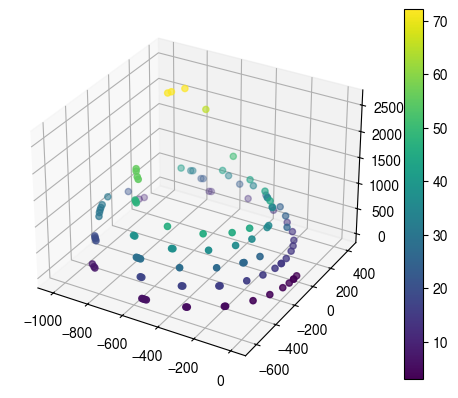

In [ ]:
multi_hits = tracker_hits[tracker_hits.particle_id == 34089]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(multi_hits.x, multi_hits.y, multi_hits.z, c=multi_hits.time, cmap="viridis")
plt.colorbar(scatter)

## Testing parquet outputs

In [122]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import polars as pl
def load_all_particles_parquet(parquet_path, event_id=None):
    """# Plan: Polars-Based Calo Explode

1. **Inspect Loader Context**

- Read current `load_all_calohits_parquet` in `22_DM_parquet_processing.ipynb` to confirm column names and list nesting.
- Note Polars version (`pl.__version__`) to ensure required expr APIs (e.g., `with_row_index`, `map`) are available.

2. **Design Cell-Level Extraction**

- Build a lazy expression (`pl.scan_parquet` → filter by `event_id`) to avoid eager full-file reads.
- Select `event_id` + scalar cell columns, call `.explode(scalar_list_cols)` to flatten one row per cell, then `.with_row_index("cell_index")` so cells and contributions share an index.

3. **Design Contribution-Level Extraction**

- From the same filtered lazy frame, keep `event_id`, `cell_index`, and contribution list columns.
- Use `pl.map(contrib_cols, lambda cols: list(zip(*cols)))` (or `arr.zip` if available) to build a list of structs per row; `explode("contrib_structs")` + `unnest` yields one row per contribution with aligned particle/energy/time.
- Collect both lazy frames, convert to pandas only if callers demand pandas.

4. **Plumb Return Values & Tests**

- Update call sites to unpack `(cells_df, contrib_df)` and adjust summary prints.
- Re-run timing cell to ensure `calohits` stage now matches other loaders and row counts are reasonable.
    Load particles data from Parquet file using Polars for fast exploding.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data (flat format with one row per particle)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        # Filter to specific event
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding by examining first non-event_id column
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype == pl.List:
        # Use Polars explode for fast unnesting
        df_exploded = df.explode(non_event_cols)
        return df_exploded.to_pandas()
    else:
        # Data is already flat
        return df.to_pandas()
def load_all_digihits_parquet(parquet_path, event_id=None):
    """
    Load digihits data from Parquet file using Polars.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data (flat format with one row per hit)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype == pl.List:
        # Use Polars explode for fast unnesting
        df_exploded = df.explode(non_event_cols)
        return df_exploded.to_pandas()
    else:
        # Data is already flat
        return df.to_pandas()
def load_all_tracks_parquet(parquet_path, event_id=None):
    """
    Load tracks data from Parquet file using Polars.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame(), None
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame(), None
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        df_pandas = df.to_pandas()
        if 'hit_ids' in df_pandas.columns:
            hits_df = df_pandas[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df_pandas.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df_pandas, None
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype != pl.List:
        # Data is already flat
        df_pandas = df.to_pandas()
        if 'hit_ids' in df_pandas.columns:
            hits_df = df_pandas[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df_pandas.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df_pandas, None
    
    # Handle hit_ids separately (nested lists that should be preserved)
    has_hit_ids = 'hit_ids' in df.columns
    
    # Separate hit_ids from other columns
    track_cols = [c for c in non_event_cols if c != 'hit_ids']
    
    if track_cols:
        # Explode track data
        df_tracks = df.select(['event_id'] + track_cols).explode(track_cols)
        tracks_df = df_tracks.to_pandas()
    else:
        tracks_df = pd.DataFrame()
    
    # Handle hit_ids separately if present
    hits_df = None
    if has_hit_ids and 'track_id' in tracks_df.columns:
        # Explode hit_ids but keep inner lists
        df_hits = df.select(['event_id', 'hit_ids']).explode('hit_ids')
        hits_df = df_hits.to_pandas()
        # Add track_id from tracks_df
        hits_df['track_id'] = tracks_df['track_id'].values
    
    return tracks_df, hits_df

def load_all_calohits_parquet(parquet_path, event_id=None):
    """
    Load calorimeter hits data from Parquet file using Polars.
    
    Returns two DataFrames:
    1. Cell-level hits (one row per calorimeter cell) without contribution columns
    2. Contribution-level data (one row per particle contribution to a cell)
    """
    import polars as pl
    import pandas as pd
    
    # 1. Lazy Scan & Filter
    # Use lazy API to avoid reading full file if we filter
    lf = pl.scan_parquet(parquet_path)
    
    if event_id is not None:
        lf = lf.filter(pl.col('event_id') == event_id)
    
    # Inspect schema to separate cell vs. contribution columns
    # We use limit(0) to get schema without reading data if collect_schema isn't available
    try:
        schema = lf.collect_schema()
    except AttributeError:
        schema = lf.limit(0).collect().schema
        
    all_cols = schema.names()
    
    # Identify contribution columns (List(List))
    contrib_cols = [c for c in all_cols if c.startswith("contrib_")]
    
    # Identify scalar cell columns (List(Scalar))
    # These are all other columns except event_id
    cell_cols = [c for c in all_cols if c != "event_id" and c not in contrib_cols]
    
    if not cell_cols:
        return pd.DataFrame(), pd.DataFrame()
        
    # 2. Cell-Level Extraction
    # We explode ALL list columns (cells + contribs) simultaneously.
    # Polars guarantees alignment (lock-step explode) when a list of columns is passed,
    # preventing Cartesian products.
    # Result: 'cell_cols' become scalars. 'contrib_cols' become List[Scalar].
    
    lf_exploded = lf.explode(cell_cols + contrib_cols).with_row_index("cell_index")
    
    # Collect cells DataFrame
    cells_df = (
        lf_exploded
        .select(["event_id", "cell_index"] + cell_cols)
        .collect()
        .to_pandas()
    )
    
    # 3. Contribution-Level Extraction
    # From the same exploded frame (now one row per cell), we select contrib columns.
    # These are now simple lists (one list per cell).
    # We explode them again to get one row per contribution.
    
    if contrib_cols:
        # Prepare rename map to remove 'contrib_' prefix
        rename_exprs = [pl.col(c).alias(c.replace("contrib_", "")) for c in contrib_cols]
        
        contributions_df = (
            lf_exploded
            .select(["event_id", "cell_index"] + contrib_cols)
            .explode(contrib_cols)  # Explode inner lists in lock-step
            .select(["event_id", "cell_index"] + rename_exprs)
            .collect()
            .to_pandas()
        )
    else:
        contributions_df = pd.DataFrame()
        
    return cells_df, contributions_df


In [108]:
# Update file paths to point to parquet files
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v2/parquet/truth/particles/hard_scatter.ttbar.v2.truth.particles.events0-9.parquet"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracker_hits/hard_scatter.ttbar.v2.reco.tracker_hits.events0-9.parquet"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/tracks/hard_scatter.ttbar.v2.reco.tracks.events0-9.parquet"
calohits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v2/parquet/reco/calo_hits/hard_scatter.ttbar.v2.reco.calo_hits.events0-9.parquet"

In [148]:
# Update file paths to point to parquet files
base = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v2/parquet")
particles_file = base / "truth/particles/hard_scatter.ttbar.v2.truth.particles.events0-7.parquet"
digihits_file = base / "reco/tracker_hits/hard_scatter.ttbar.v2.reco.tracker_hits.events0-7.parquet"
tracks_file = base / "reco/tracks/hard_scatter.ttbar.v2.reco.tracks.events0-7.parquet"
calohits_file = base / "reco/calo_hits/hard_scatter.ttbar.v2.reco.calo_hits.events0-7.parquet"

In [152]:
%%time
# Test loading a single event from parquet with improved functions
global_event_id = 5
particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
digihits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
tracks_df, track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
calohits_cells_df, calohits_contrib_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(particles_df)} rows")
print(f"  Digihits: {len(digihits_df)} rows")
print(f"  Tracks: {len(tracks_df)} rows")
print(f"  Calohit cells: {len(calohits_cells_df)} rows")
print(f"  Calohit contributions: {len(calohits_contrib_df)} rows")
if track_hits_df is not None:
    print(f"  Track hit associations: {len(track_hits_df)} rows")

Loaded event 5:
  Particles: 5055 rows
  Digihits: 6058 rows
  Tracks: 64 rows
  Calohit cells: 31865 rows
  Calohit contributions: 40705 rows
  Track hit associations: 64 rows
CPU times: user 198 ms, sys: 20.8 ms, total: 219 ms
Wall time: 59.9 ms


In [153]:
particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,num_tracker_hits,num_calo_hits,vertex_primary,parent_id,primary
0,5,39,-321,0.493680,58.601589,-1.0,-0.026015,0.003744,-38.220306,0.078581,0.991475,0.437857,58.589485,0.013934,-37.015617,0,0,1,9,True
1,5,40,111,0.134980,74.864403,0.0,-0.026015,0.003744,-38.220306,0.078581,1.094013,0.675108,74.853241,0.016848,-37.045673,0,0,1,9,True
2,5,41,213,0.654662,160.566299,1.0,-0.026015,0.003744,-38.220306,0.078581,-0.299584,0.146204,160.564621,NaN,NaN,0,0,1,9,True
3,5,42,-211,0.139570,154.460663,-1.0,-0.026015,0.003744,-38.220306,0.078581,0.146140,-0.204730,154.460388,NaN,NaN,0,0,1,9,True
4,5,43,2214,1.447397,1497.771240,1.0,-0.026015,0.003744,-38.220306,0.078581,0.030522,-0.314543,1497.770508,NaN,NaN,0,0,1,9,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5050,5,5707,11,0.000511,0.153060,-1.0,-363.852448,-168.032730,5304.445312,18.052923,-0.091750,0.041962,0.115101,304.140656,5006.681641,0,11,1,5676,False
5051,5,5708,22,0.000000,7.127594,0.0,-0.025926,0.003578,-38.209175,0.078618,0.013824,-0.157568,7.125839,-0.025515,-37.946518,0,0,1,496,False
5052,5,5709,22,0.000000,8.223498,0.0,-0.025926,0.003578,-38.209175,0.078618,0.108931,-0.070555,8.222474,-0.011091,-36.707298,0,0,1,496,False
5053,5,5710,22,0.000000,4.147099,0.0,-0.026009,0.003723,-38.219368,0.078584,0.006881,-0.030661,4.146980,0.000000,0.000000,0,0,1,494,False


In [130]:
calohits_contrib_df

,event_id,cell_index,particle_ids,energies,times
0,0,0,1144,0.000440,10.667375
1,0,1,839,0.000141,10.814469
2,0,2,1810,0.000078,11.617600
3,0,3,1125,0.000211,11.255672
4,0,4,355,0.000215,5.368598
...,...,...,...,...,...
16432,0,9467,355,0.000758,8.157822
16433,0,9468,1953,0.000284,5.305988
16434,0,9469,871,0.000237,10.702003
16435,0,9470,355,0.000147,5.739599


In [131]:
digihits_df

,event_id,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,detector
0,0,-83.024139,-34.695446,-1516.800049,6.169310,276,-83.010536,-34.706856,-1516.800049,16,4,6,0
1,0,-82.940315,-34.693161,-1515.599976,6.165298,276,-82.946671,-34.696507,-1515.599976,16,4,7,0
2,0,15.143629,103.171005,-1516.800049,6.183334,281,15.132997,103.176018,-1516.800049,16,4,20,0
3,0,22.720257,82.764702,-1516.800049,6.262533,1878,22.711218,82.780426,-1516.800049,16,4,20,0
4,0,-0.125000,44.974998,-1515.599976,6.156443,332,-0.116253,44.968601,-1515.599976,16,4,21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1631,0,846.989685,-513.830811,3025.500000,11.090474,461,806.167419,-491.318451,3025.500000,30,12,175,8
1632,0,846.826782,-512.437988,3020.500000,11.070227,461,806.379517,-488.027557,3020.500000,30,12,176,8
1633,0,484.927704,862.914856,3025.500000,13.759956,2031,451.442261,802.162964,3025.377686,30,12,189,8
1634,0,459.144836,877.120789,3025.500000,17.125969,434,444.862610,851.145935,3025.500000,30,12,189,8


In [132]:
tracks_df

,event_id,majority_particle_id,d0,z0,phi,theta,qop,track_id
0,0,299,0.026979,196.094666,-2.826057,2.153862,-0.433579,0
1,0,88,-0.025032,196.200241,-2.705793,0.443637,0.333322,1
2,0,94,0.026024,195.818420,-2.062616,0.120335,0.025389,2
3,0,274,-0.179318,195.665115,-1.994147,0.105592,-0.085780,3
4,0,362,0.043832,196.071365,-1.521535,0.386880,-0.020649,4
5,0,326,-0.020064,196.064804,0.656747,1.923840,0.651897,5
6,0,370,-0.383710,196.465546,0.872791,2.031974,0.228827,6
7,0,353,-0.041451,195.915451,0.817467,1.963714,-0.332504,7
8,0,358,0.025474,195.989212,0.795230,1.891153,-0.139021,8
9,0,372,0.025927,196.300705,0.784546,2.048068,-0.195180,9


In [133]:
track_hits_df

,event_id,hit_ids,track_id
0,0,"[758, 434, 429, 307, 179, 148]",0
1,0,"[1576, 1574, 1553, 1552, 1109, 1079, 867, 759,...",1
2,0,"[641, 600, 565, 518, 496, 477, 460, 79]",2
3,0,"[1238, 1187, 643, 602, 548, 554, 517, 525, 495...",3
4,0,"[1606, 1605, 1570, 1568, 1136, 1110, 1081, 885...",4
5,0,"[1466, 1465, 979, 895, 791, 453, 452, 332, 216...",5
6,0,"[1412, 1408, 1391, 1389, 1012, 920, 901, 798, ...",6
7,0,"[1427, 1426, 1431, 1430, 1404, 1403, 1017, 925...",7
8,0,"[1422, 1421, 1400, 1397, 1015, 918, 905, 795, ...",8
9,0,"[1418, 1417, 1395, 1394, 1016, 922, 903, 799, ...",9


## Summary: Parquet Structure

**Writing side** (using PyArrow groupby):
- Creates proper Arrow list arrays (efficient)
- Schema: `event_id: int64, particle_id: list<int64>, px: list<double>, ...`

**Reading side** (using awkward arrays):
1. Read parquet → pandas (columns have list objects)
2. Convert to awkward with `.tolist()` (handles nested lists)
3. Use `ak.flatten()` to explode lists
4. Use `ak.broadcast_arrays()` to repeat event_id
5. Convert back to pandas with flat structure

This is **straightforward and efficient** - awkward is designed exactly for this pattern!

## Validation Checks

In [134]:
# Add number of hits of particle to tracks_df
tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
tracks_df["hit_ids"] = track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = digihits_df[digihits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)

In [135]:
tracks_df

,event_id,majority_particle_id,d0,z0,phi,theta,qop,track_id,num_particle_hits,num_track_hits,hit_ids,num_shared_hits
0,0,299,0.026979,196.094666,-2.826057,2.153862,-0.433579,0,16,6,"[758, 434, 429, 307, 179, 148]",6
1,0,88,-0.025032,196.200241,-2.705793,0.443637,0.333322,1,11,11,"[1576, 1574, 1553, 1552, 1109, 1079, 867, 759,...",11
2,0,94,0.026024,195.818420,-2.062616,0.120335,0.025389,2,8,8,"[641, 600, 565, 518, 496, 477, 460, 79]",8
3,0,274,-0.179318,195.665115,-1.994147,0.105592,-0.085780,3,15,15,"[1238, 1187, 643, 602, 548, 554, 517, 525, 495...",15
4,0,362,0.043832,196.071365,-1.521535,0.386880,-0.020649,4,14,13,"[1606, 1605, 1570, 1568, 1136, 1110, 1081, 885...",13
5,0,326,-0.020064,196.064804,0.656747,1.923840,0.651897,5,14,11,"[1466, 1465, 979, 895, 791, 453, 452, 332, 216...",10
6,0,370,-0.383710,196.465546,0.872791,2.031974,0.228827,6,14,14,"[1412, 1408, 1391, 1389, 1012, 920, 901, 798, ...",14
7,0,353,-0.041451,195.915451,0.817467,1.963714,-0.332504,7,16,16,"[1427, 1426, 1431, 1430, 1404, 1403, 1017, 925...",16
8,0,358,0.025474,195.989212,0.795230,1.891153,-0.139021,8,12,12,"[1422, 1421, 1400, 1397, 1015, 918, 905, 795, ...",12
9,0,372,0.025927,196.300705,0.784546,2.048068,-0.195180,9,13,13,"[1418, 1417, 1395, 1394, 1016, 922, 903, 799, ...",13


In [136]:
tracks_df["efficiency"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]

In [137]:
print(f"Efficiency: {tracks_df.efficiency.mean()}, Purity: {tracks_df.purity.mean()}")

Efficiency: 0.9411630036630036, Purity: 0.994949494949495


In [123]:
for global_event_id in range(0, 10):
    particles_df = load_all_particles_parquet(particles_file, event_id = global_event_id)
    digihits_df = load_all_digihits_parquet(digihits_file, event_id = global_event_id)
    tracks_df, track_hits_df = load_all_tracks_parquet(tracks_file, event_id = global_event_id)
    tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
    tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
    tracks_df["hit_ids"] = track_hits_df.hit_ids
    tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)
    tracks_df["completeness"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
    tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]
    print(f"Completeness: {tracks_df.completeness.mean()}, Purity: {tracks_df.purity.mean()}")


Completeness: 0.9411630036630036, Purity: 0.994949494949495
Completeness: 0.9373568297511312, Purity: 0.9952059659090909
Completeness: 0.9322816072816072, Purity: 0.9861111111111112
Completeness: 0.9618846562242788, Purity: 0.9943176320534811
Completeness: 0.980304070929071, Purity: 0.9842575038597766
Completeness: 0.959230819731739, Purity: 0.9903674450549451
Completeness: 0.949727758743104, Purity: 0.99421387790953
Completeness: 0.9628891941391943, Purity: 0.9969135802469135


KeyError: 'majority_particle_id'

Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 0')

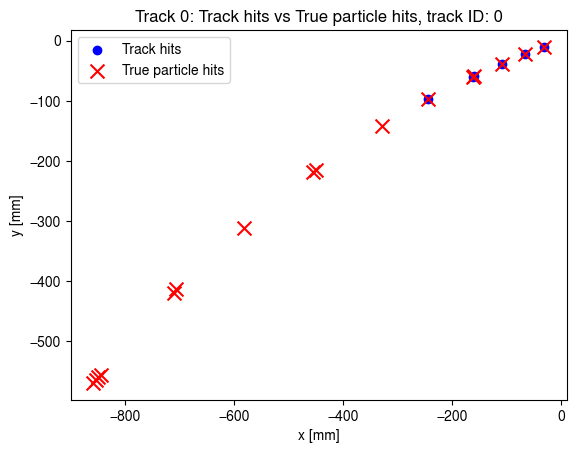

In [138]:
track_index = 0
track_hit_ids = track_hits_df.iloc[track_index].hit_ids

plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {tracks_df.track_id.iloc[track_index]}")

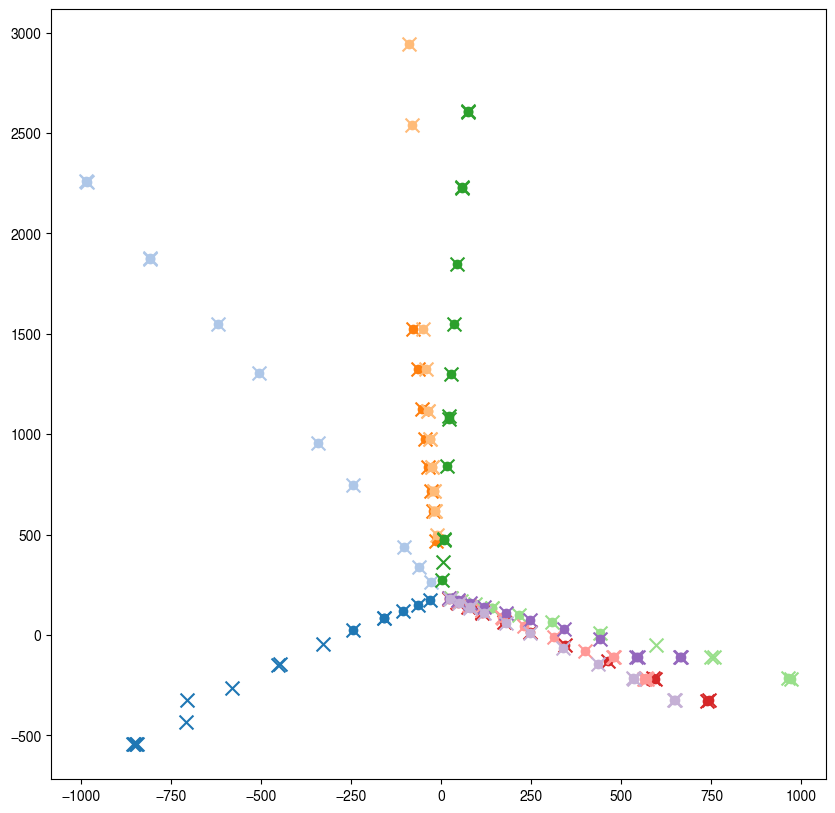

In [139]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

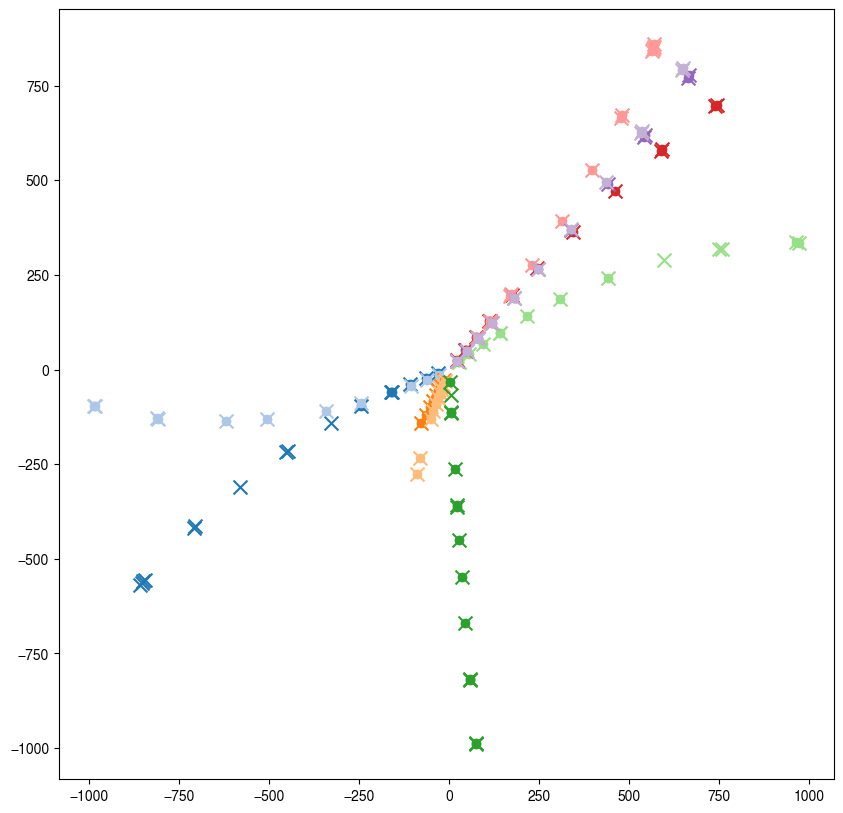

In [140]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

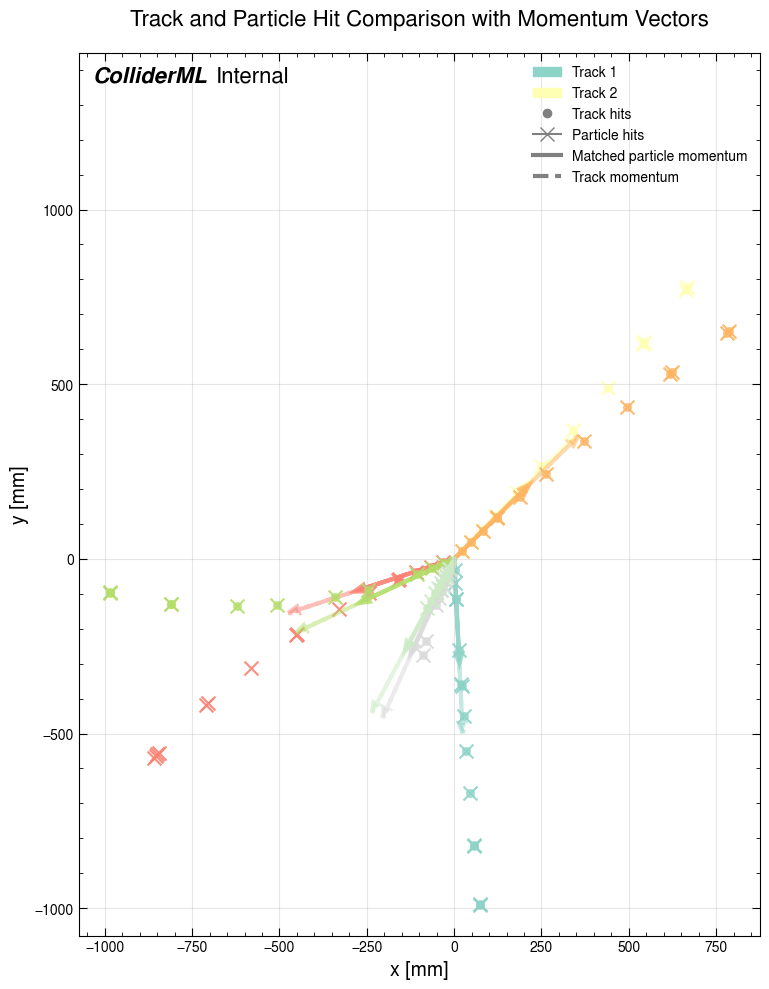

In [141]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


In [150]:
paths = {
    "particles": base / "truth/particles/hard_scatter.ttbar.v2.truth.particles.events0-7.parquet",
    "digihits": base / "reco/tracker_hits/hard_scatter.ttbar.v2.reco.tracker_hits.events0-7.parquet",
    "tracks": base / "reco/tracks/hard_scatter.ttbar.v2.reco.tracks.events0-7.parquet",
    "calohits": base / "reco/calo_hits/hard_scatter.ttbar.v2.reco.calo_hits.events0-7.parquet",
}

expected = {
    "particles": {
        "event_id": pa.uint32(),
        "particle_id": pa.list_(pa.uint64()),
        "primary": pa.list_(pa.bool_()),
    },
    "digihits": {
        "event_id": pa.uint32(),
        "volume_id": pa.list_(pa.uint8()),
        "layer_id": pa.list_(pa.uint16()),
        "surface_id": pa.list_(pa.uint32()),
        "detector": pa.list_(pa.uint8()),
    },
    "tracks": {
        "event_id": pa.uint32(),
        "track_id": pa.list_(pa.uint16()),
        "hit_ids": pa.list_(pa.list_(pa.uint32())),
    },
    "calohits": {
        "event_id": pa.uint32(),
        "detector": pa.list_(pa.uint8()),
    },
}

In [151]:
for name, path in paths.items():
    print(f"=== {name} ===")
    schema = pq.read_schema(path)
    print(schema)
    if name in expected:
        for col, dtype in expected[name].items():
            field = schema.field(col)
            assert field.type == dtype, f"{name}.{col}: {field.type} != {dtype}"
        print("  ✓ expected dtypes OK")
    print()

=== particles ===
event_id: uint32
particle_id: list<element: uint64>
  child 0, element: uint64
pdg_id: list<element: int32>
  child 0, element: int32
mass: list<element: float>
  child 0, element: float
energy: list<element: float>
  child 0, element: float
charge: list<element: float>
  child 0, element: float
vx: list<element: float>
  child 0, element: float
vy: list<element: float>
  child 0, element: float
vz: list<element: float>
  child 0, element: float
time: list<element: float>
  child 0, element: float
px: list<element: float>
  child 0, element: float
py: list<element: float>
  child 0, element: float
pz: list<element: float>
  child 0, element: float
perigee_d0: list<element: double>
  child 0, element: double
perigee_z0: list<element: double>
  child 0, element: double
num_tracker_hits: list<element: uint16>
  child 0, element: uint16
num_calo_hits: list<element: uint16>
  child 0, element: uint16
vertex_primary: list<element: uint16>
  child 0, element: uint16
parent_i